In [22]:
import os
import pandas as pd
import numpy as np
import re
import nltk
import pickle
import itertools
import matplotlib.pyplot as plt


In [24]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [25]:
# 📦 Ensure only needed NLTK resources are downloaded
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
# 🔧 Setup preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if pd.isnull(text):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))  # remove punctuation
    text = text.lower()
    tokens = text.split()  # ✅ replaces nltk.word_tokenize to avoid punkt
    filtered = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(filtered)

In [27]:
# 📄 Load Dataset
csv_file = 'train.csv'
if not os.path.exists(csv_file):
    print(f"❌ Error: '{csv_file}' not found.")
    exit()

df = pd.read_csv(csv_file)

In [28]:
# ✅ Validate columns
if 'Statement' not in df.columns or 'Label' not in df.columns:
    print("❌ Required columns 'Statement' and 'Label' not found in CSV.")
    exit()

In [29]:
# 🔁 Preprocess text
print("🔁 Cleaning and preprocessing text...")
df['Statement'] = df['Statement'].apply(preprocess_text)


🔁 Cleaning and preprocessing text...


In [30]:
# 🔠 Encode labels
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])  # FAKE = 0, REAL = 1


In [31]:
# 🧠 Feature extraction
vectorizer = TfidfVectorizer(max_df=0.7)
X = vectorizer.fit_transform(df['Statement'])
y = df['Label']

In [32]:
# 🔀 Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
# 🚀 Train model
model = PassiveAggressiveClassifier(max_iter=1000)
model.fit(X_train, y_train)

PassiveAggressiveClassifier()

In [34]:
# 📊 Evaluate
y_pred = model.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy * 100:.2f}%")



✅ Model Accuracy: 54.00%


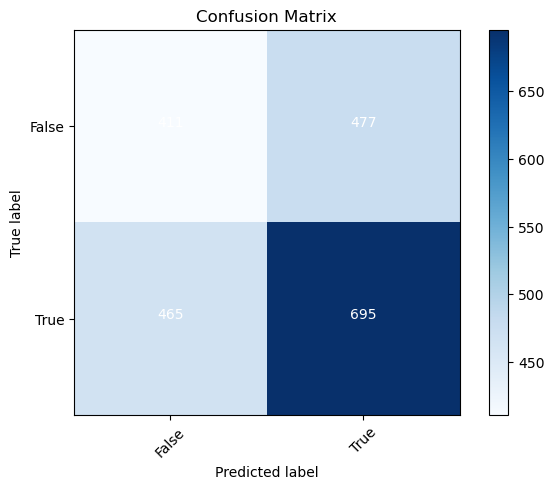

In [35]:
# 📉 Confusion Matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

cm = metrics.confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, classes=label_encoder.classes_)


In [36]:
# 💾 Save model and components
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
pickle.dump(label_encoder, open("label_encoder.pkl", "wb"))

print("✅ Model, vectorizer, and label encoder saved!")


✅ Model, vectorizer, and label encoder saved!


In [37]:
def predict_news(news_text):
    try:
        model = pickle.load(open("model.pkl", "rb"))
        vectorizer = pickle.load(open("vectorizer.pkl", "rb"))
        label_encoder = pickle.load(open("label_encoder.pkl", "rb"))

        cleaned = preprocess_text(news_text)
        vect = vectorizer.transform([cleaned])
        prediction = model.predict(vect)
        label = label_encoder.inverse_transform(prediction)[0]

        # Check type and format properly
        if isinstance(label, str):
            print(f"\n📰 Prediction: This news is likely **{label.upper()}**")
        else:
            print(f"\n📰 Prediction: This news is likely **{label}**")

    except Exception as e:
        print(f"❌ Error during prediction: {e}")


In [38]:

# 🧪 Test Example
predict_news("Government launches new policy for rural health development.")


📰 Prediction: This news is likely **False**
